# Workflow Test: Vacuum Gripper
### Geometries, Gripper, Grasp Sampler

In [1]:
import os
from os.path import join as pjoin
import sys
import numpy as np
import open3d as o3d
import yaml
from copy import deepcopy

# Import our custom modules
from src.grippers.parallel_gripper import ParallelGripper as Gripper, ParallelGripperConfig as GripperConfig
from src.grasping.parallel_sampler import ParallelGraspSampler as GraspSampler, ParallelSamplerConfig as SamplerConfig
import src.utils.geometry_utils as gu
from src.generic_geometry import GenericGeometry


### Load Configs and data

In [9]:
# franka_path = pjoin("gripper_parameter", "franka_parallel.yaml")
franka_path = pjoin("gripper_parameter", "Franka_2m.yaml")
# object_path = pjoin("Test_part", "pringles", "clouds","merged_cloud.ply")
# object_path = pjoin("Test_part","Verification_examples","combined.ply")
object_path = pjoin("Test_part","cracker_box","clouds","merged_cloud.ply")

gripper = Gripper(franka_path)
pcd = GenericGeometry(object_path)


✅ Geometry set: mesh (open3d)
🔧 Parallel Gripper initialized with max opening: 0.080m
[Open3D WARNING] geometry::TriangleMesh appears to be a geometry::PointCloud (only contains vertices, but no triangles).
[Open3D] Loaded PointCloud: Test_part/cracker_box/clouds/merged_cloud.ply
✅ Geometry set: point_cloud (open3d)


In [10]:
gripper.visualize()

In [11]:
pcd.visualize()

## Create Grasp Sampler

In [12]:
config = SamplerConfig(
    # --- Parâmetros Matemáticos ---
    plane_angle_thresh=5.0,
    min_score=0.1,
    distance_threshold=0.001,          # Limiar do RANSAC (1mm em metros)
    margin_points_between_planes=0.001, # Margem das fatias (1mm em metros)
    
    # --- Flags de Visualização (Deixe True para ver o passo a passo) ---
    no_image=False,                           # Mude para True se quiser rodar rápido sem abrir janelas
    show_all_planes_and_normals=True,         # Mostra todos os planos encontrados pelo RANSAC
    show_planes_parallel_clustering=True,     # Mostra as cores dos grupos paralelos
    show_plane_pairs=True,                    # Destaca o par atual sendo avaliado
    show_plane_pair_and_proj_in_pcd=True,     # Mostra as projeções centrais
    show_proj_pts_p1=True,                    # Mostra a sobreposição (Overlap)
    show_proj_pts_p2=True,                    # Mostra o corpo da peça entre os dedos
    show_proj_pts_p3=True,                    # Mostra a verificação de folga dos dedos
    show_proj_pts_p4=True,                    # Mostra a verificação de folga da base
    show_proj_pts_p5=True                     # Mostra a verificação de folga do braço
)

# 4. Instanciar e Rodar o Sampler
print("🚀 Iniciando a amostragem de pegas paralelas com Debug Visual...")
sampler = GraspSampler(gripper=gripper, config=config)

🚀 Iniciando a amostragem de pegas paralelas com Debug Visual...


### Sample Grasps

In [13]:
pcd.scale(0.6, center=True)
pcd.get_dimensions_report()

{'extents_xyz': array([0.0587, 0.1039, 0.1416]),
 'diagonal': 0.1852,
 'likely_unit': 'meters',
 'suggested_voxel_size': 0.00185,
 'details': 'Type: Open3D PointCloud. Size: 0.06 x 0.10 x 0.14. Unit: METERS.'}

In [14]:
pcd_down = pcd.downsample(voxel_size=0.001)
GenericGeometry(geometry=pcd_down).visualize()

Downsampling with voxel_size=0.001...
✅ Geometry set: point_cloud (open3d)


In [15]:
# Run the sampling pipeline
# pcd_down = pcd.downsample(voxel_size=0.003)
pcd_down.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.01, max_nn=30))
pcd_down.orient_normals_consistent_tangent_plane(k=15)
grasps = sampler.sample_grasps(pcd_down)

print(f"\nResult: Found {len(grasps)} valid grasps.")

if len(grasps) > 0:
    best_grasp = grasps[0]
    print(f"Top Grasp Score: {best_grasp.score:.4f}")
    print(f"Top Grasp Position: {best_grasp.contact_point}")
else:
    print("No valid grasps found. Check thresholds.")

🧠 [Auto-Tuning] Distância média: 0.0008m
🧠 [Auto-Tuning] Limite dinâmico definido para: 259 pontos/plano
🚀 Iniciando extração de planos (Min pts/plano: 259)...
   -> RANSAC extraiu 25 planos brutos.
   -> Após a fusão, restam 12 planos estruturais consolidados.

-------- Avaliando Par: 1/7 --------
Distância entre planos: 0.0386m | Abertura Máx: 0.0780m

-------- Avaliando Par: 2/7 --------
Distância entre planos: 0.0347m | Abertura Máx: 0.0780m

-------- Avaliando Par: 3/7 --------
Distância entre planos: 0.0029m | Abertura Máx: 0.0780m

-------- Avaliando Par: 4/7 --------
Distância entre planos: 0.0971m | Abertura Máx: 0.0780m
Ignorado: Peça muito fina ou muito grossa para a garra.

-------- Avaliando Par: 5/7 --------
Distância entre planos: 0.0954m | Abertura Máx: 0.0780m
Ignorado: Peça muito fina ou muito grossa para a garra.

-------- Avaliando Par: 6/7 --------
Distância entre planos: 0.0015m | Abertura Máx: 0.0780m

-------- Avaliando Par: 7/7 --------
Distância entre planos: 

In [ ]:
# for c in sampler.get_best_candidates(8):
for c in [best_grasp]:
# for c in [sampler.candidates[50]]:
    sampler.visualize_grasp(pcd_down, c)

In [9]:
# # for c in sampler.get_best_candidates(8):
for c in sampler.valid_candidates:
# # for c in [sampler.candidates[50]]:
    sampler.visualize_grasp(pcd_down, c)

✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...
✅ Geometry set: mesh (open3d)
Applying rigid transformation...


KeyboardInterrupt: 

(array([7.217e+03, 0.000e+00, 0.000e+00, 1.600e+01, 1.710e+02, 1.030e+02,
        5.900e+01, 9.000e+01, 1.460e+02, 2.230e+02, 6.500e+01, 5.400e+01,
        4.900e+01, 7.500e+01, 9.000e+01, 1.700e+01, 5.000e+00, 6.000e+00,
        1.100e+01, 3.000e+00]),
 array([0.        , 0.04409569, 0.08819139, 0.13228708, 0.17638278,
        0.22047847, 0.26457416, 0.30866986, 0.35276555, 0.39686124,
        0.44095694, 0.48505263, 0.52914833, 0.57324402, 0.61733971,
        0.66143541, 0.7055311 , 0.74962679, 0.79372249, 0.83781818,
        0.88191388]),
 <BarContainer object of 20 artists>)

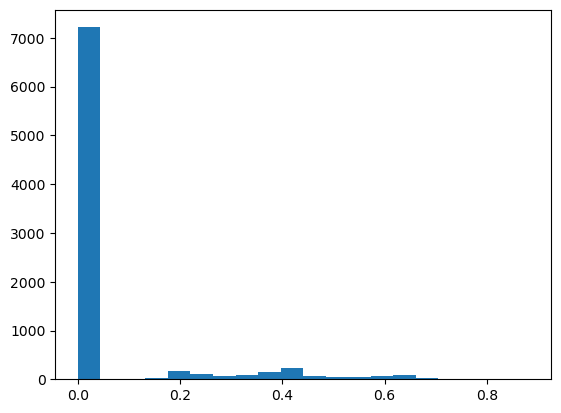

In [20]:
import matplotlib.pyplot as plt
plt.hist(list(map(lambda c: c.score_details.get("seal_score") , sampler.candidates)), bins=20)

In [34]:
sampler.visualize_grasp(pcd_down, 
                        sorted(sampler.candidates, 
                        key=lambda c: c.score_details.get('seal_score',0), reverse=True
                        )[0])

✅ Geometry set: mesh (open3d)
Applying rigid transformation...


In [78]:
sampler.visualize_candidates_heatmap(pcd_down, valid_only=False)

In [82]:
sampler.visualize_candidates_heatmap(pcd_down,attribute='verticality', valid_only=False)

In [92]:
sampler.visualize_candidates_heatmap(pcd_down,attribute='torque', valid_only=False)

In [81]:
sampler.visualize_candidates_heatmap(pcd_down,attribute='seal_score', valid_only=False)